<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/11_Wine_Quality_Decision_Tree_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WINE QUALITY CLASSIFICATION PROJECT

First five rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4

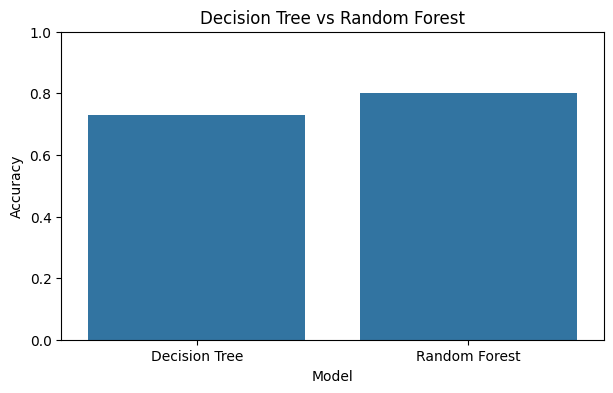

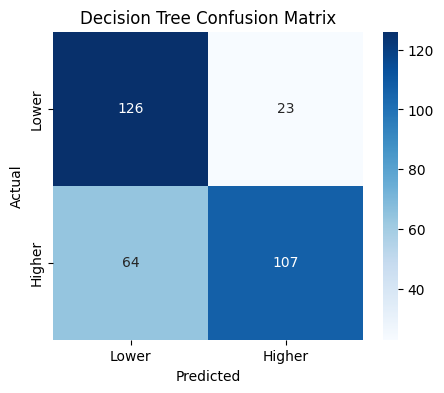

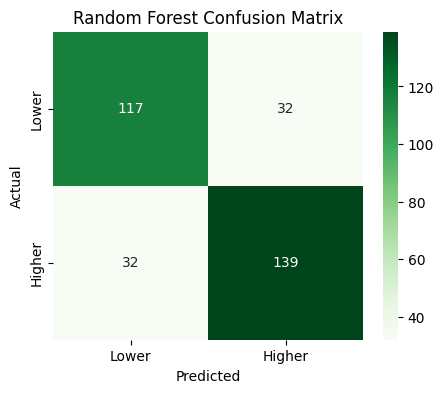

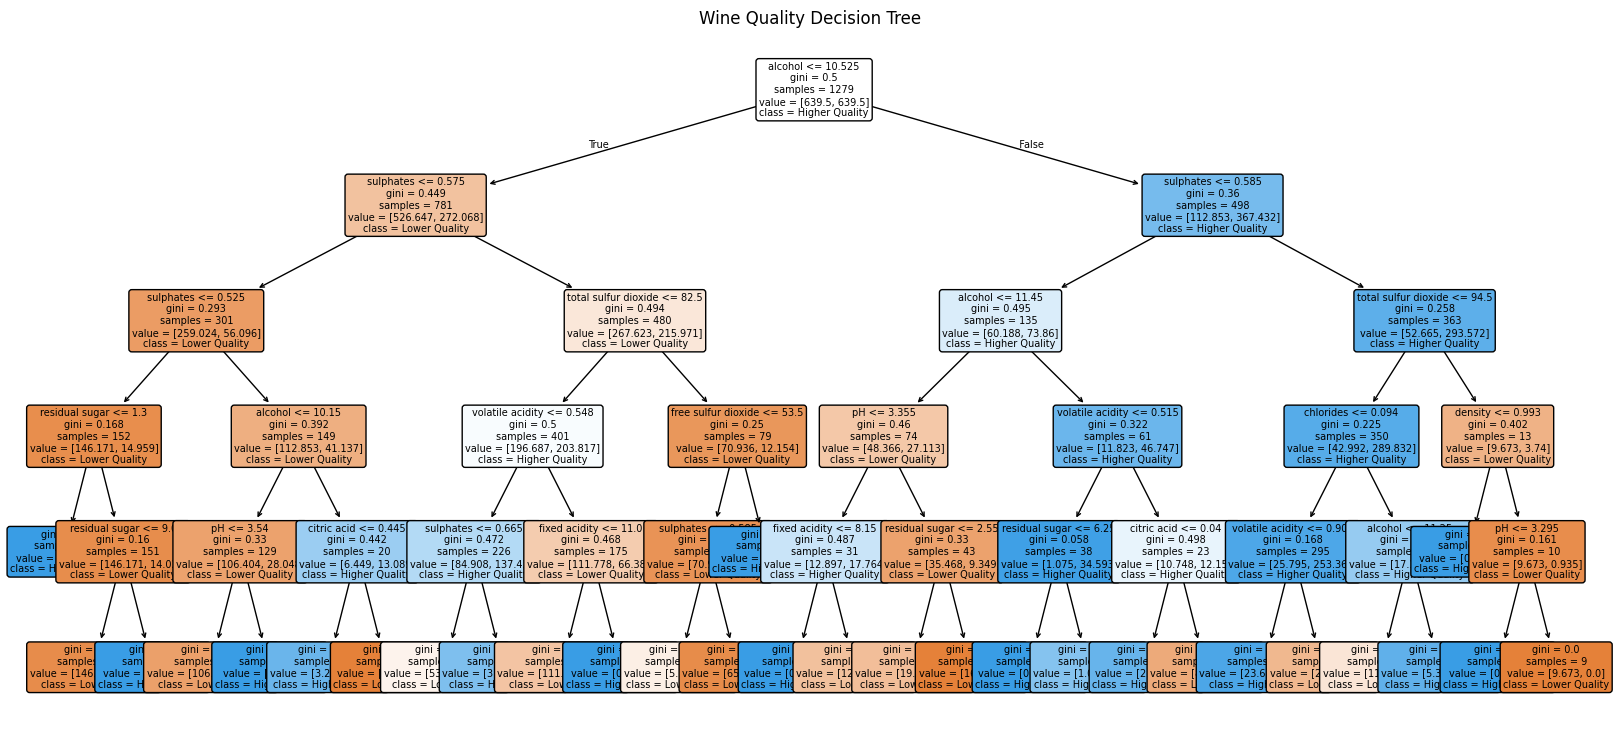


Top 10 Important Features:
alcohol                 0.183663
sulphates               0.135461
volatile acidity        0.112159
total sulfur dioxide    0.101122
density                 0.088501
chlorides               0.071348
fixed acidity           0.067614
citric acid             0.064646
pH                      0.063039
free sulfur dioxide     0.057834
dtype: float64


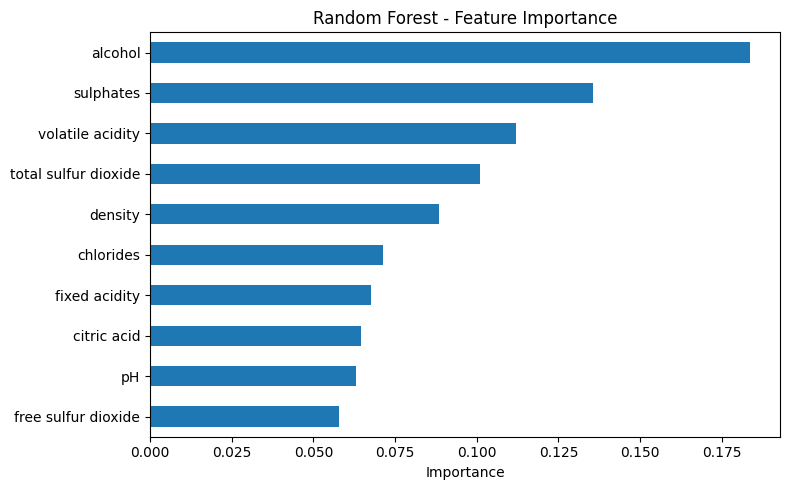


Prediction and comparison CSV files saved.
PROGRAM 11 COMPLETED SUCCESSFULLY!


In [1]:

# PROGRAM 11: WINE QUALITY - DECISION TREE & RANDOM FOREST

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 1. Load the Wine Quality dataset
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)

df = pd.read_csv(url, sep=";")

print("WINE QUALITY CLASSIFICATION PROJECT")
print("=" * 55)

# 2. Explore the dataset
print("\nFirst five rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nOriginal quality distribution:")
print(df["quality"].value_counts().sort_index())

# 3. Convert wine quality into two educational classes
# Quality 6 or above = Higher Quality
# Quality below 6 = Lower Quality
df["quality_category"] = (df["quality"] >= 6).astype(int)

print("\nClass distribution (0 = Lower, 1 = Higher):")
print(df["quality_category"].value_counts())

# 4. Prepare features and target
X = df.drop(columns=["quality", "quality_category"])
y = df["quality_category"]

# 5. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 6. Train the Decision Tree
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

# 7. Train the Random Forest
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)

# 8. Compare model performance
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print("\nMODEL COMPARISON")
print(results.to_string(index=False))

print("\nDECISION TREE CLASSIFICATION REPORT")
print(classification_report(
    y_test, dt_pred,
    target_names=["Lower Quality", "Higher Quality"],
    zero_division=0
))

print("\nRANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(
    y_test, rf_pred,
    target_names=["Lower Quality", "Higher Quality"],
    zero_division=0
))

# 9. Plot model accuracy
plt.figure(figsize=(7, 4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Decision Tree vs Random Forest")
plt.ylim(0, 1)
plt.show()

# 10. Decision Tree confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Lower", "Higher"],
    yticklabels=["Lower", "Higher"]
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. Random Forest confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Lower", "Higher"],
    yticklabels=["Lower", "Higher"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Visualize the Decision Tree
plt.figure(figsize=(20, 9))
plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Lower Quality", "Higher Quality"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Wine Quality Decision Tree")
plt.show()

# 13. Random Forest feature importance
importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 14. Save predictions and model comparison
predictions = pd.DataFrame({
    "Actual_Quality_Category": y_test.to_numpy(),
    "Decision_Tree_Prediction": dt_pred,
    "Random_Forest_Prediction": rf_pred
})

predictions.to_csv("wine_quality_predictions.csv", index=False)
results.to_csv("wine_quality_model_comparison.csv", index=False)

print("\nPrediction and comparison CSV files saved.")
print("PROGRAM 11 COMPLETED SUCCESSFULLY!")